# 07. Zero-Leakage Split-Before-Windowing Forensics

This ablation defends the data-integrity claim behind the final SOC pipeline. The fatal leakage pattern in battery sequence modeling is windowing before splitting: adjacent sliding windows share most of their timesteps, so a train window can contain nearly the same physical trajectory as a test window. That produces optimistic metrics without true generalization.

The repository's `preprocessing_v4` pipeline prevents this by splitting continuous 1 Hz profiles first, then building sliding windows inside each split. It also saves timestamp-key tensors so the claim can be audited computationally instead of trusted by inspection. This notebook verifies the saved metadata and recomputes pairwise intersections directly with `np.intersect1d`.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and data/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PROCESSED_ROOT = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})

print(f'Project root: {ROOT}')
print(f'Processed data root: {PROCESSED_ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Processed data root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\data\processed
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Metadata-level audit

First check the declarative contract saved by each processed dataset: split-before-windowing must be enabled, 1 Hz sampling must be preserved where recorded, and all pipeline-generated leakage counters must equal zero.


In [2]:
metadata_paths = sorted(PROCESSED_ROOT.glob('**/metadata*.json'))
if not metadata_paths:
    raise FileNotFoundError(f'No metadata JSON files found under {PROCESSED_ROOT}')

metadata_records = []
for path in metadata_paths:
    meta = json.loads(path.read_text(encoding='utf-8'))
    verification = meta.get('verification', {})
    split_flag = meta.get('split_before_windowing')
    sampling_hz = meta.get('sampling_hz')

    if split_flag is not None:
        assert split_flag is True, f'{path}: split_before_windowing is not True'
    if sampling_hz is not None:
        assert abs(float(sampling_hz) - 1.0) < 1e-9, f'{path}: sampling_hz is not 1.0'
    for key, value in verification.items():
        assert int(value) == 0, f'{path}: metadata verification {key}={value}'

    metadata_records.append({
        'Dataset': str(path.parent.relative_to(ROOT)),
        'Metadata file': path.name,
        'Version': meta.get('version', 'unknown'),
        'Method': meta.get('method', 'contextual'),
        'Sampling Hz': sampling_hz,
        'Split before windowing': split_flag,
        'Verification keys': ', '.join(sorted(verification.keys())),
        'Verification sum': int(sum(int(v) for v in verification.values())) if verification else 0,
    })

metadata_df = pd.DataFrame(metadata_records)
display(metadata_df)
print('METADATA CONTRACT PASSED: split-before-windowing flags and saved verification counters are clean.')


,Dataset,Metadata file,Version,Method,Sampling Hz,Split before windowing,Verification keys,Verification sum
0,data\processed\v4_scenario_A,metadata_v4.json,v4,V_proxy + strict 1Hz + split-before-windowing,1.0,True,"train_test, train_test_key, train_val, train_v...",0
1,data\processed\v4_scenario_B,metadata_v4.json,v4,V_proxy + strict 1Hz + split-before-windowing,1.0,True,"train_test, train_test_key, train_val, train_v...",0
2,data\processed\v5_contextual\scenario_A,metadata_v5_contextual.json,v5_contextual,v4 sequence features + causal OCV-rest/history...,1.0,True,"train_test_used_key, train_val_used_key, val_t...",0
3,data\processed\v5_contextual\scenario_B,metadata_v5_contextual.json,v5_contextual,v4 sequence features + causal OCV-rest/history...,1.0,True,"train_test_used_key, train_val_used_key, val_t...",0


METADATA CONTRACT PASSED: split-before-windowing flags and saved verification counters are clean.


## Direct timestamp-key intersection proof

Metadata flags are useful, but the hard proof is set intersection. The cell below loads saved split tensors, flattens them into unique timestamp or profile-second keys, and computes `np.intersect1d` across train/validation/test. Any nonzero count is a blocker. Sentinel keys below zero are excluded for optional contextual keys only.


In [3]:
PAIRINGS = [('train', 'val'), ('train', 'test'), ('val', 'test')]
KEY_FAMILIES = ['timestamp_key', 'timestamp_ns', 'context_key', 'rest_key']

def load_unique_keys(path, drop_negative=False):
    arr = np.load(path, mmap_mode='r')
    flat = np.asarray(arr).reshape(-1)
    if drop_negative:
        flat = flat[flat >= 0]
    if flat.size == 0:
        return np.array([], dtype=np.int64)
    return np.unique(flat.astype(np.int64, copy=False))

def intersection_count(unique_a, unique_b):
    if unique_a.size == 0 or unique_b.size == 0:
        return 0
    return int(np.intersect1d(unique_a, unique_b, assume_unique=True).size)

def verify_processed_dir(data_dir):
    rows = []
    for family in KEY_FAMILIES:
        files = {split: data_dir / f'{family}_{split}.npy' for split in ['train', 'val', 'test']}
        if not all(path.exists() for path in files.values()):
            continue
        drop_negative = family in {'context_key', 'rest_key'}
        uniques = {split: load_unique_keys(path, drop_negative=drop_negative) for split, path in files.items()}
        for left, right in PAIRINGS:
            count = intersection_count(uniques[left], uniques[right])
            rows.append({
                'Dataset': str(data_dir.relative_to(ROOT)),
                'Key family': family,
                'Pair': f'{left}_vs_{right}',
                'Unique left': int(uniques[left].size),
                'Unique right': int(uniques[right].size),
                'Overlap count': count,
            })
    return rows

all_overlap_rows = []
for meta_path in metadata_paths:
    all_overlap_rows.extend(verify_processed_dir(meta_path.parent))

overlap_df = pd.DataFrame(all_overlap_rows)
if overlap_df.empty:
    raise RuntimeError('No split key arrays were found for direct leakage verification.')

display(overlap_df)
bad = overlap_df[overlap_df['Overlap count'] != 0]
assert bad.empty, 'Temporal leakage detected by direct np.intersect1d proof:\n' + bad.to_string(index=False)
print('ZERO-LEAKAGE CERTIFICATION PASSED: all direct split intersections evaluate to 0.')


,Dataset,Key family,Pair,Unique left,Unique right,Overlap count
0,data\processed\v4_scenario_A,timestamp_key,train_vs_val,159380,95340,0
1,data\processed\v4_scenario_A,timestamp_key,train_vs_test,159380,193910,0
2,data\processed\v4_scenario_A,timestamp_key,val_vs_test,95340,193910,0
3,data\processed\v4_scenario_A,timestamp_ns,train_vs_val,159380,95340,0
4,data\processed\v4_scenario_A,timestamp_ns,train_vs_test,159380,193910,0
5,data\processed\v4_scenario_A,timestamp_ns,val_vs_test,95340,193910,0
6,data\processed\v4_scenario_B,timestamp_key,train_vs_val,313840,44650,0
7,data\processed\v4_scenario_B,timestamp_key,train_vs_test,313840,89370,0
8,data\processed\v4_scenario_B,timestamp_key,val_vs_test,44650,89370,0
9,data\processed\v4_scenario_B,timestamp_ns,train_vs_val,313840,44650,0


ZERO-LEAKAGE CERTIFICATION PASSED: all direct split intersections evaluate to 0.


## Scenario composition from v4 metadata

Reviewer-facing data ledgers should show where windows enter train, validation, and test splits. The table and figure below are reconstructed from `metadata_v4.json`, not typed by hand.


In [4]:
TEMP_ORDER = ['40degC', '25degC', '10degC', '0degC', 'n10degC', 'n20degC']
TEMP_LABEL = {
    '40degC': '40 C',
    '25degC': '25 C',
    '10degC': '10 C',
    '0degC': '0 C',
    'n10degC': '-10 C',
    'n20degC': '-20 C',
}

composition_rows = []
for scenario in ['A', 'B']:
    meta_path = PROCESSED_ROOT / f'v4_scenario_{scenario}' / 'metadata_v4.json'
    if not meta_path.exists():
        continue
    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    counts = meta['split_window_counts']
    for temp in TEMP_ORDER:
        composition_rows.append({
            'Scenario': scenario,
            'Temperature': TEMP_LABEL[temp],
            'Train windows': int(counts['train'].get(temp, 0)),
            'Validation windows': int(counts['val'].get(temp, 0)),
            'Test windows': int(counts['test'].get(temp, 0)),
        })

composition_df = pd.DataFrame(composition_rows)
display(composition_df)
assert not composition_df.empty, 'No v4 scenario composition metadata found.'


,Scenario,Temperature,Train windows,Validation windows,Test windows
0,A,40 C,0,0,6148
1,A,25 C,8199,790,0
2,A,10 C,7442,675,0
3,A,0 C,0,7619,0
4,A,-10 C,0,0,7387
5,A,-20 C,0,0,5379
6,B,40 C,4245,448,1079
7,B,25 C,6346,789,1712
8,B,10 C,5750,674,1520
9,B,0 C,5286,618,1395


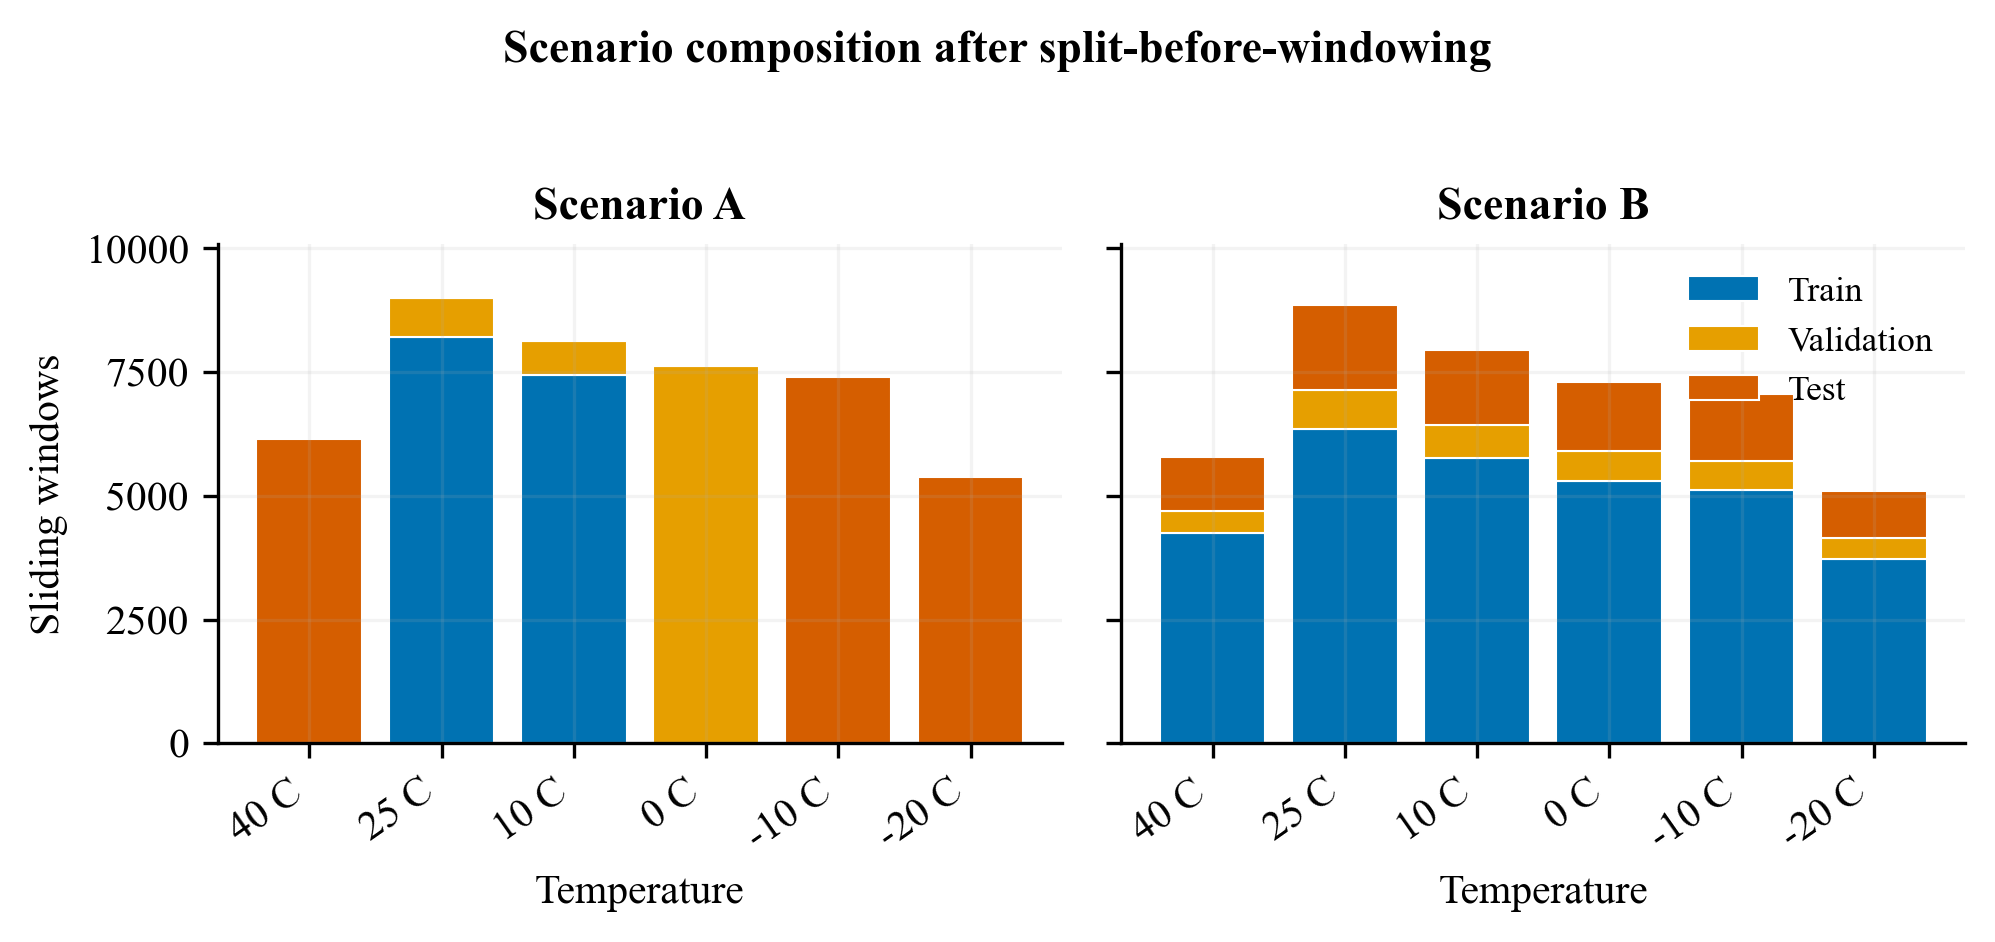

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_07_split_leakage_forensics.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_07_split_leakage_forensics.png


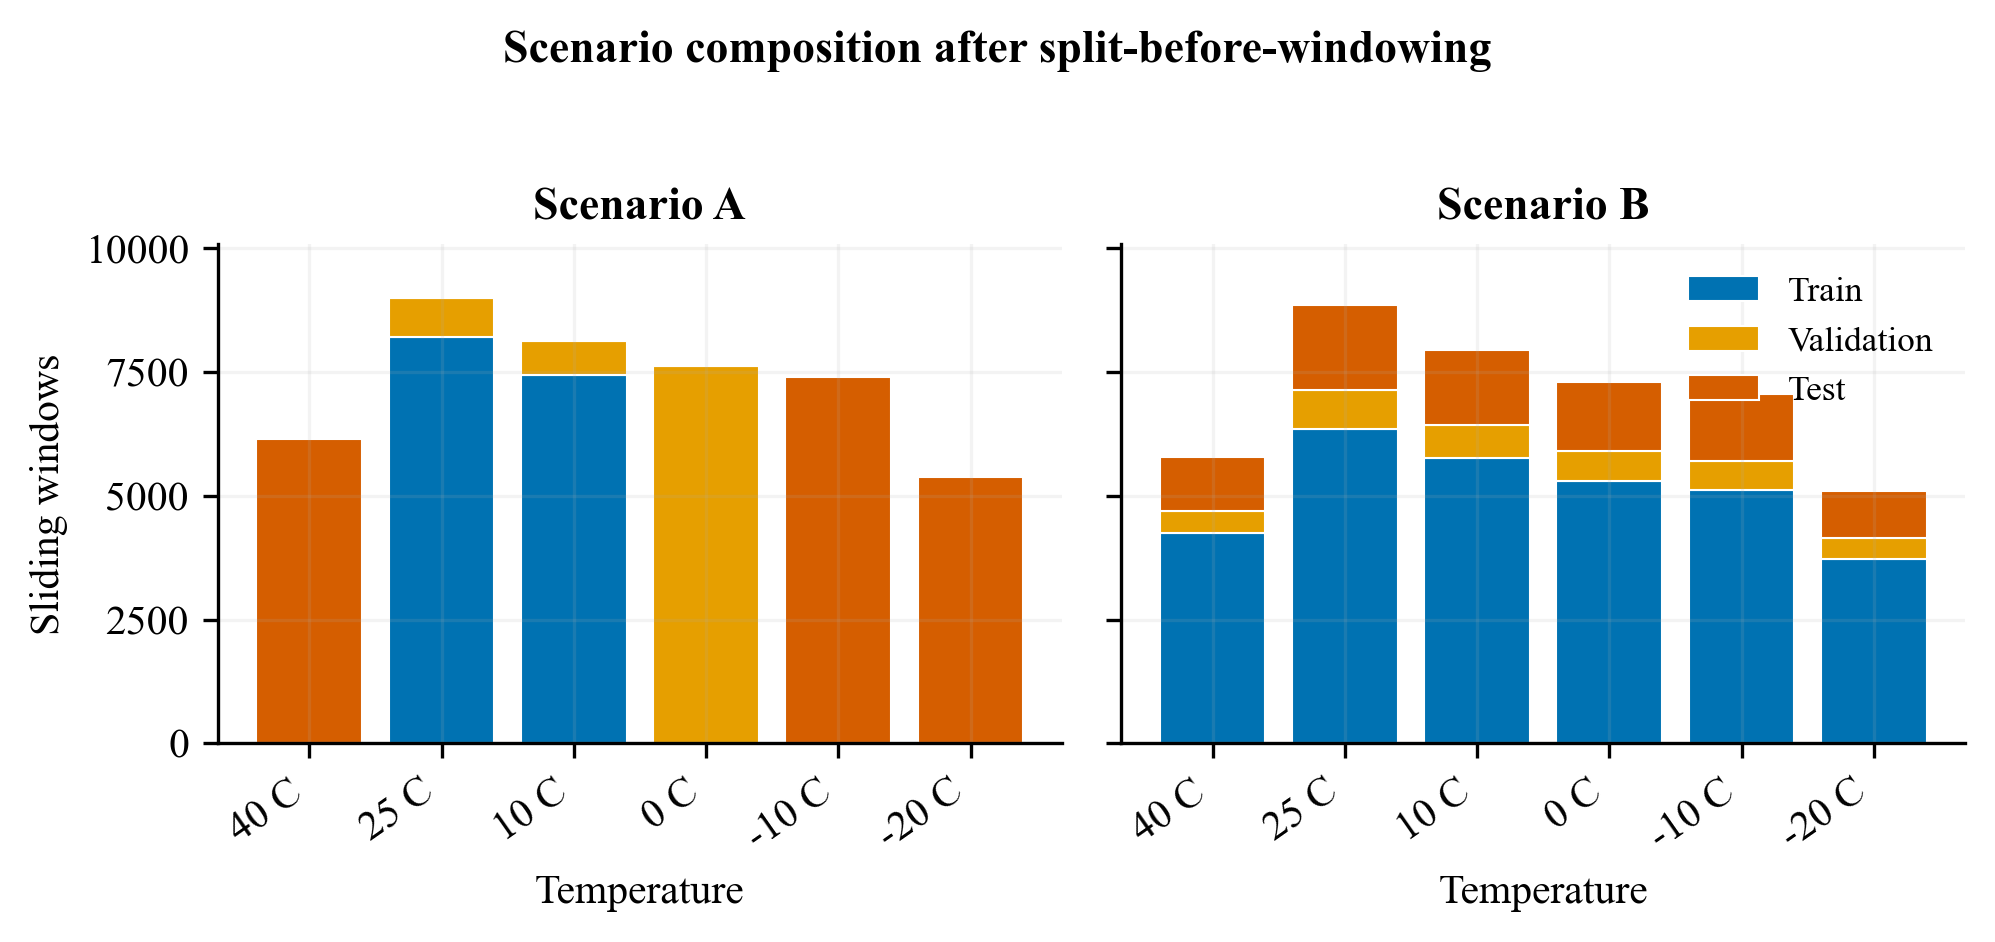

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0), sharey=True)
split_cols = ['Train windows', 'Validation windows', 'Test windows']
split_colors = ['#0072B2', '#E69F00', '#D55E00']

for ax, scenario in zip(axes, ['A', 'B']):
    sub = composition_df[composition_df['Scenario'] == scenario].copy()
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub), dtype=float)
    for col, color in zip(split_cols, split_colors):
        values = sub[col].to_numpy(dtype=float)
        ax.bar(x, values, bottom=bottom, color=color, edgecolor='white', linewidth=0.5, label=col.replace(' windows', ''))
        bottom += values
    ax.set_title(f'Scenario {scenario}')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['Temperature'], rotation=35, ha='right')
    ax.set_xlabel('Temperature')
    ax.set_ylim(0, max(1, composition_df[split_cols].sum(axis=1).max() * 1.12))
axes[0].set_ylabel('Sliding windows')
axes[1].legend(loc='upper right')
fig.suptitle('Scenario composition after split-before-windowing', y=1.03, fontsize=11, fontweight='bold')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_07_split_leakage_forensics.pdf'
png_path = FIG_DIR / 'fig_07_split_leakage_forensics.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Interpretation

If any overlap count above is nonzero, the experiment is invalid because a physical timestep appears in more than one split. A zero intersection across timestamp keys means the train, validation, and test windows are constructed from disjoint profile-second sets. This is the computational defense that the pipeline performs splitting before sliding-window expansion.
